#### Libraries used

In [98]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

##### Load train data

In [99]:

IN_KAGGLE = os.path.exists('/kaggle/input')

if IN_KAGGLE:
    # Kaggle غيّر اسم الفولدر ده للأساسي في المسابقة على 
    DATA_DIR = Path('/kaggle/input/house-prices-advanced-regression-techniques')
else:
    DATA_DIR = Path.cwd().parent / "datasets" / "raw"

train_data = pd.read_csv(DATA_DIR / 'train.csv')
train_data.shape

(1460, 81)

In [100]:
def summary(df):
    # إعداد عرض كل الصفوف والأعمدة بشكل دائم أو مؤقت
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    
    summary_df = pd.DataFrame({
        'Dtype': df.dtypes,
        'Null_Count': df.isnull().sum(),
        'Null_Percent': (df.isnull().sum() / len(df)) * 100,
        'N_Unique': df.nunique()
    })
    
    # عشان لو حابب تخزنه في متغير بعدين DataFrame الي return عمل 
    return summary_df

summary(train_data)

,Dtype,Null_Count,Null_Percent,N_Unique
Id,int64,0,0.000000,1460
MSSubClass,int64,0,0.000000,15
MSZoning,str,0,0.000000,5
LotFrontage,float64,259,17.739726,110
LotArea,int64,0,0.000000,1073
Street,str,0,0.000000,2
Alley,str,1369,93.767123,2
LotShape,str,0,0.000000,4
LandContour,str,0,0.000000,4
Utilities,str,0,0.000000,2


In [101]:
# Type of rear passageway for the house (Grvl <> طوب , pave <> ممهد)

train_data['Alley']= train_data['Alley'].fillna('None')
train_data['Alley'].value_counts()

Alley
None    1369
Grvl      50
Pave      41
Name: count, dtype: int64

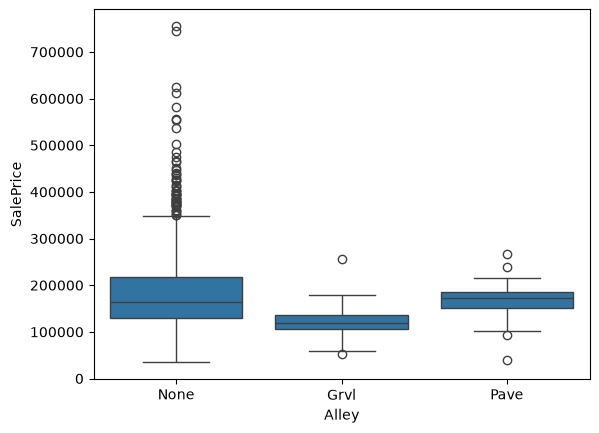

In [102]:
def box_plot_fun(var):

    sns.boxplot(x = var , y = 'SalePrice' ,data = train_data )

box_plot_fun('Alley')

In [103]:
train_data['PoolQC'] = train_data['PoolQC'].fillna('None')
train_data['PoolQC'].value_counts()

PoolQC
None    1453
Gd         3
Ex         2
Fa         2
Name: count, dtype: int64

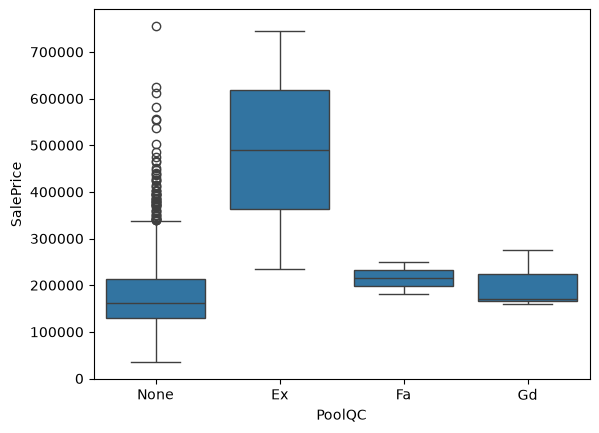

In [104]:
box_plot_fun('PoolQC')

In [105]:
train_data['Fence'] = train_data['Fence'].fillna('None')
train_data['Fence'].value_counts()

Fence
None     1179
MnPrv     157
GdPrv      59
GdWo       54
MnWw       11
Name: count, dtype: int64

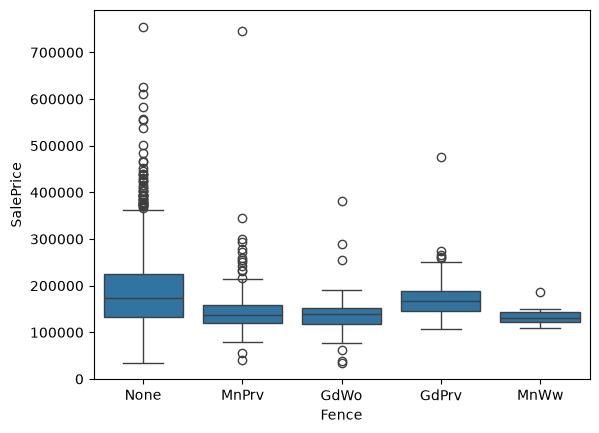

In [106]:
box_plot_fun('Fence')

In [107]:
train_data['MiscFeature'] = train_data['MiscFeature'].fillna('None')
train_data['MiscFeature'].value_counts()

MiscFeature
None    1406
Shed      49
Gar2       2
Othr       2
TenC       1
Name: count, dtype: int64

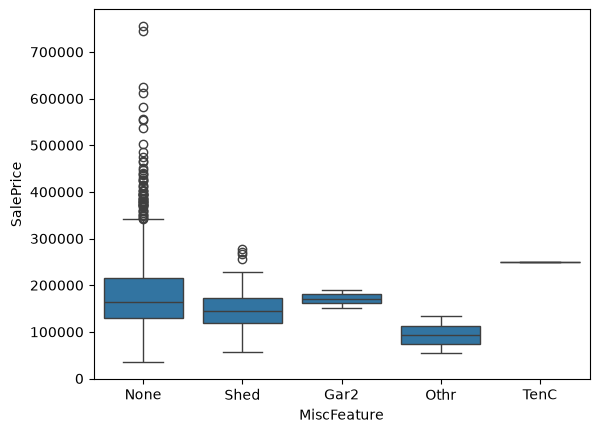

In [108]:
box_plot_fun('MiscFeature')

In [109]:
train_data['MasVnrType'] = train_data['MasVnrType'].fillna('None')
train_data['MasVnrType'].value_counts()

MasVnrType
None       872
BrkFace    445
Stone      128
BrkCmn      15
Name: count, dtype: int64

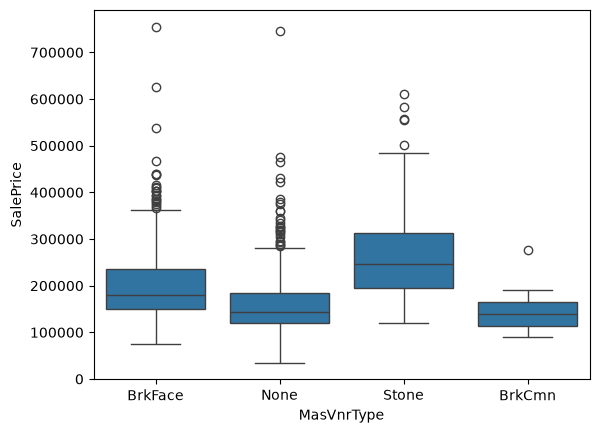

In [110]:
box_plot_fun('MasVnrType')

In [111]:
train_data['FireplaceQu'] = train_data['FireplaceQu'].fillna('None')
train_data['FireplaceQu'].value_counts()

FireplaceQu
None    690
Gd      380
TA      313
Fa       33
Ex       24
Po       20
Name: count, dtype: int64

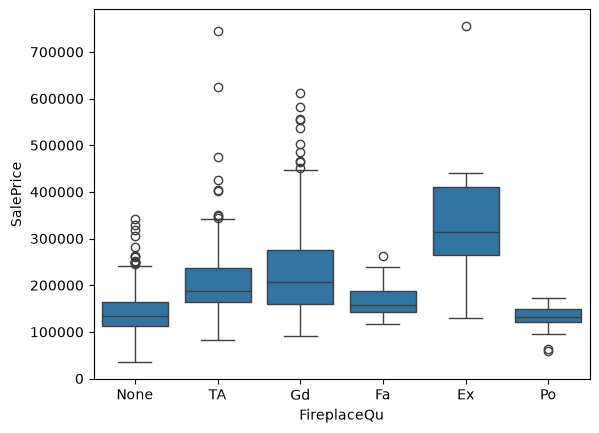

In [112]:
box_plot_fun('FireplaceQu')

In [113]:
num_columns = train_data.select_dtypes(include = np.number)
num_columns.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [114]:
num_con_columns =  num_columns.drop(

['Id' ,'MSSubClass' , 'OverallQual' , 'OverallCond',
'YearBuilt' , 'YearRemodAdd' , 'MoSold' ,  'YrSold' ] , axis = 1  )

num_con_columns.columns

Index(['LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'SalePrice'],
      dtype='str')

#### Outliers Detection and Remove

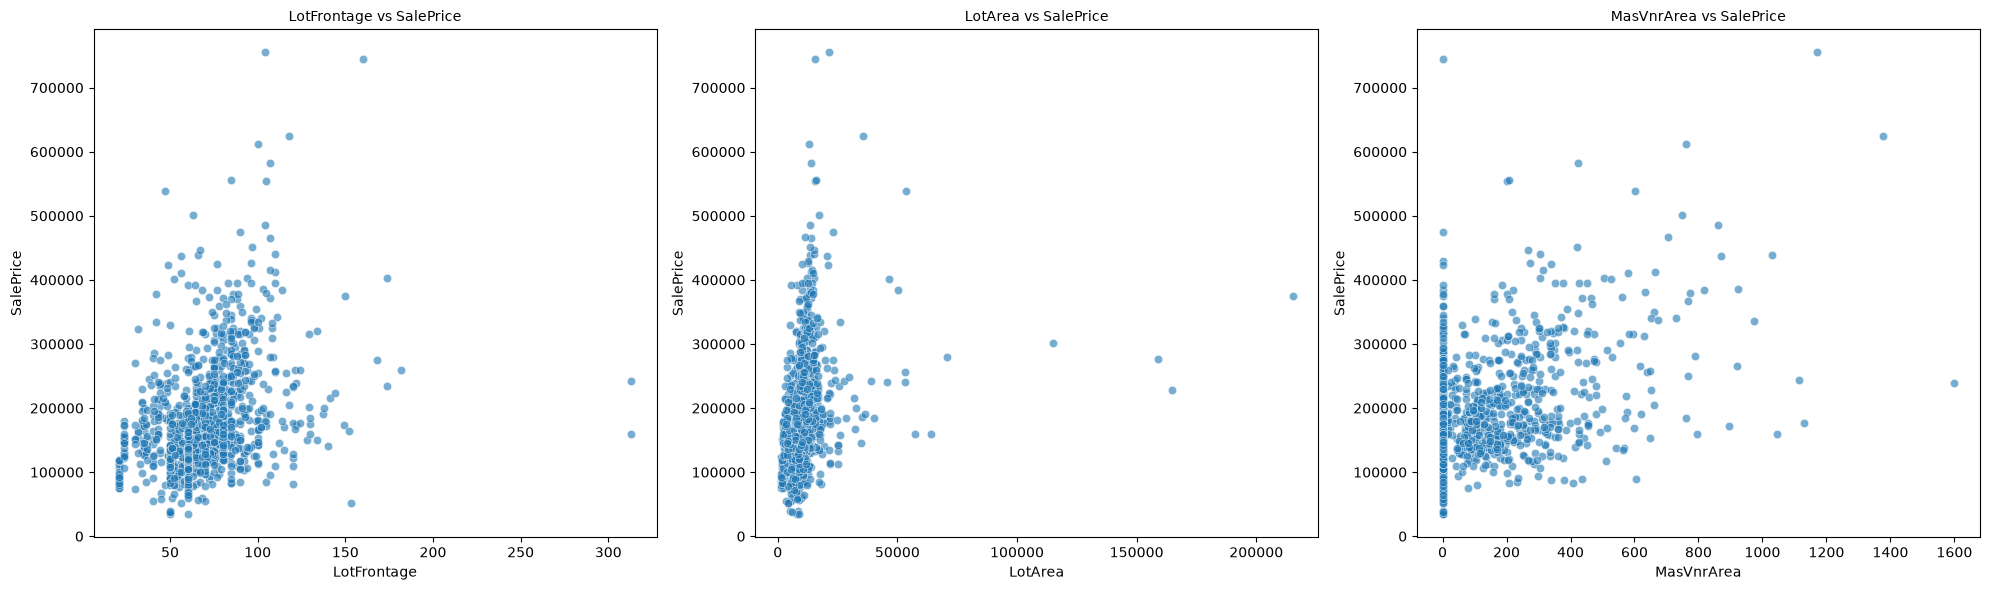

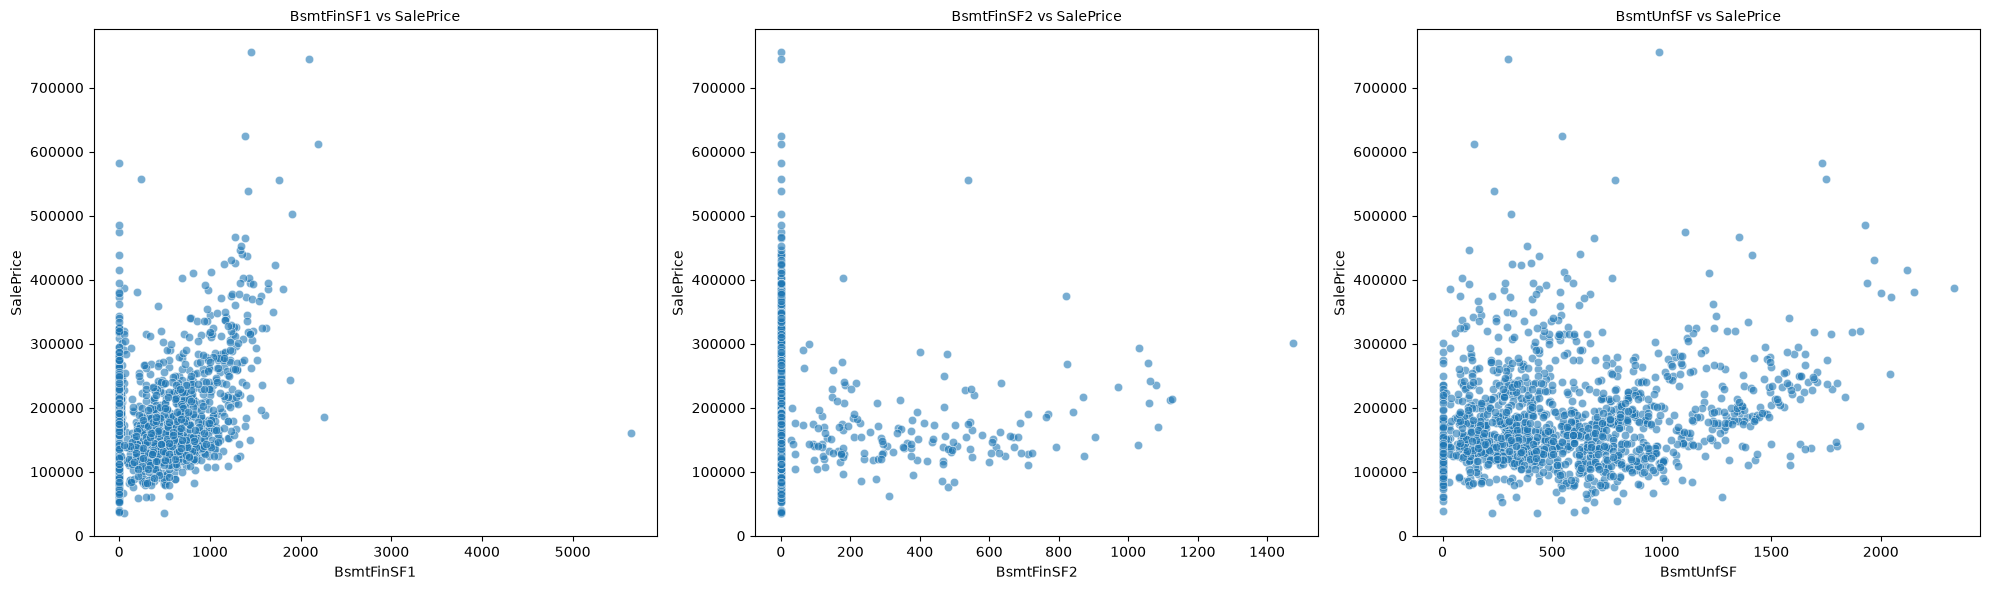

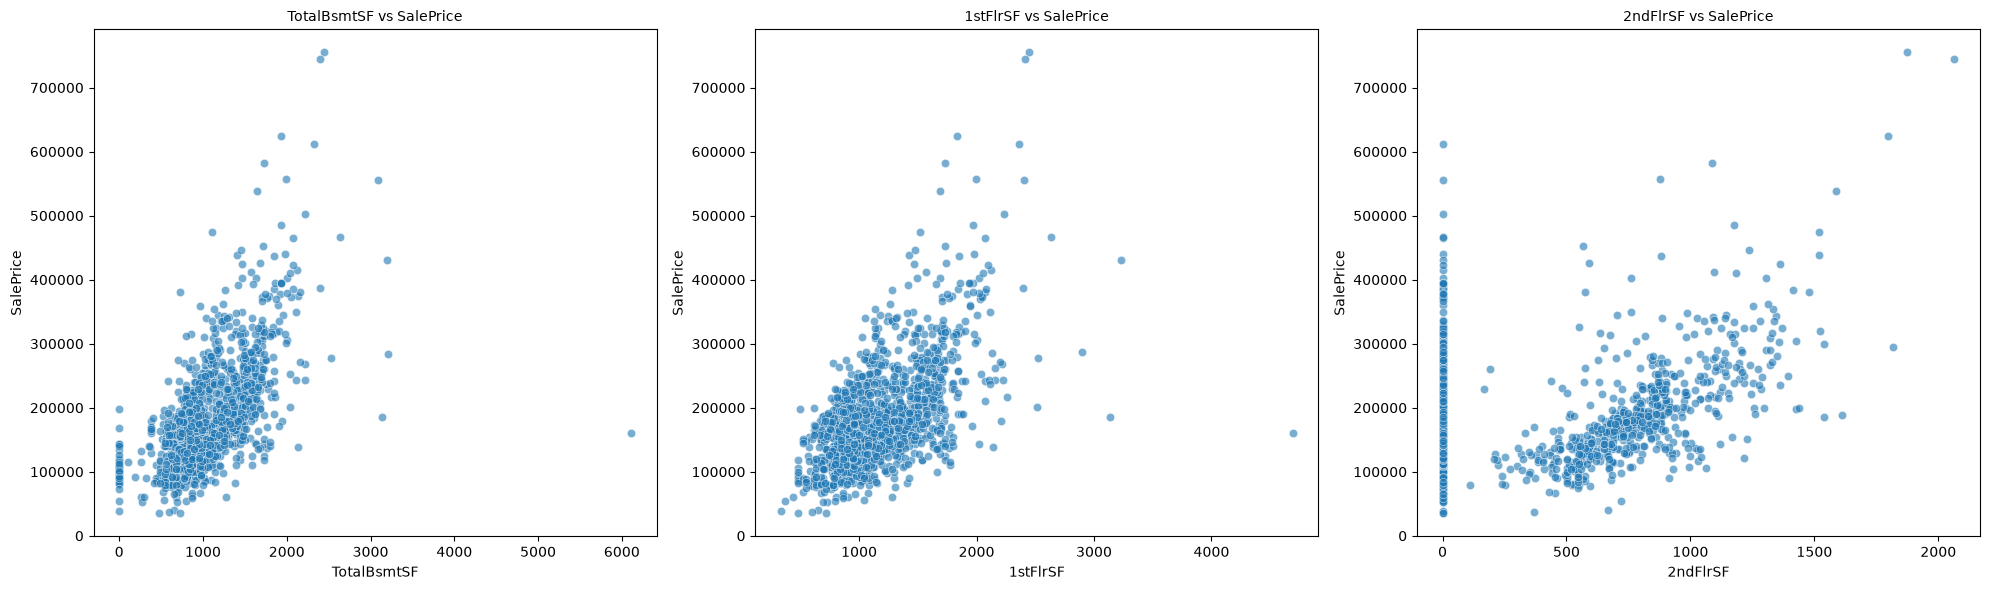

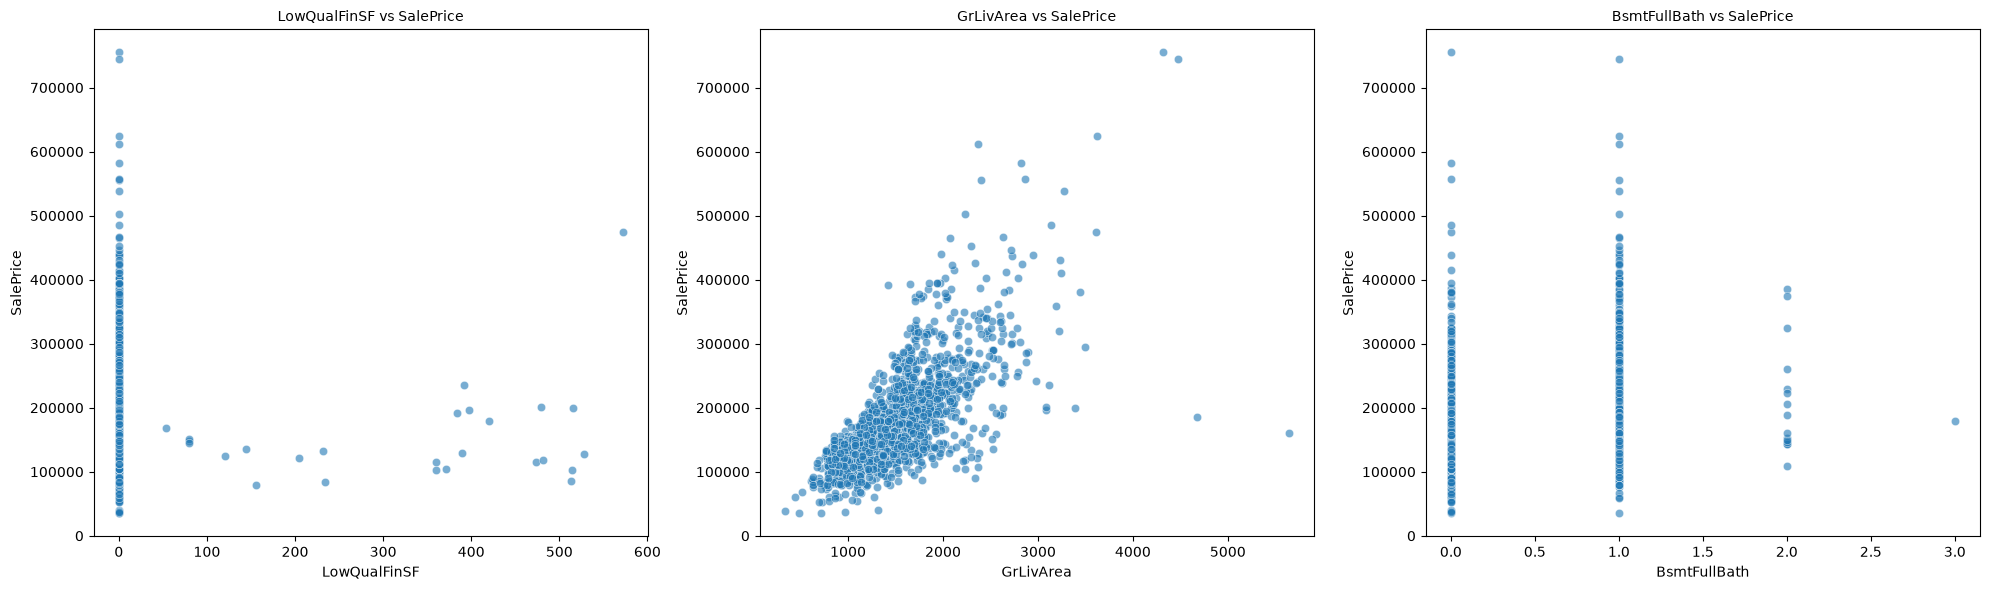

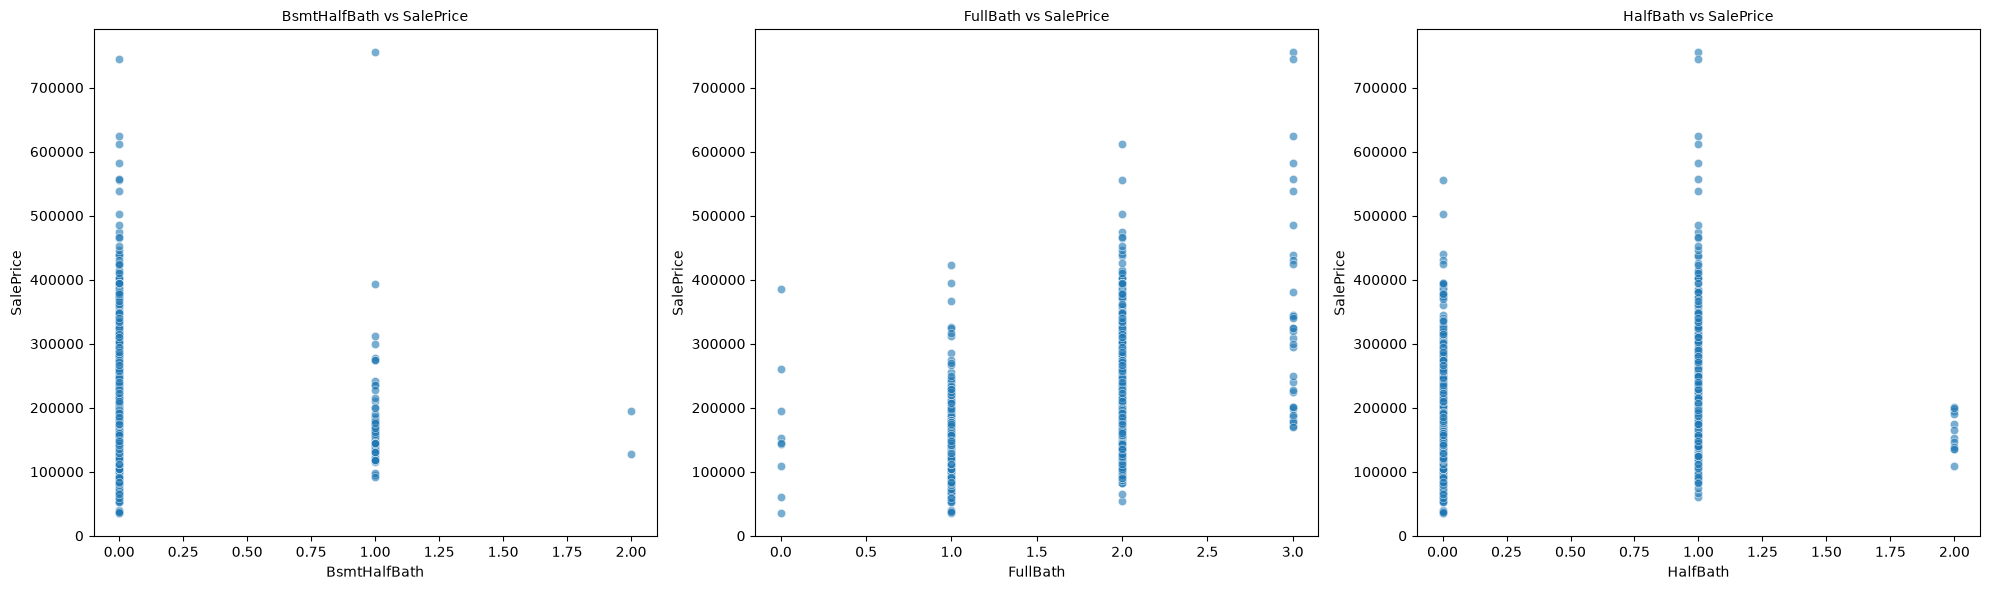

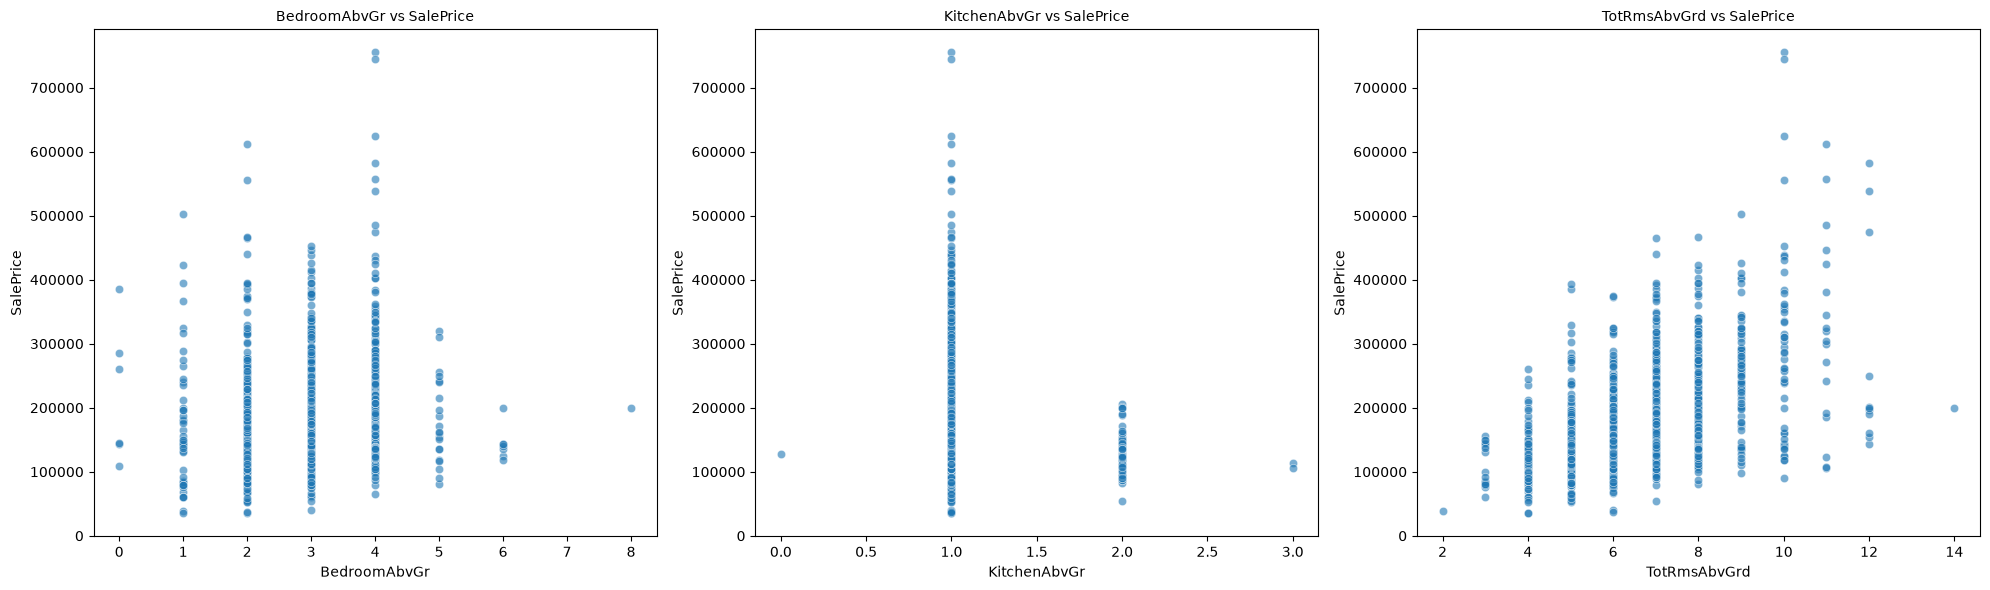

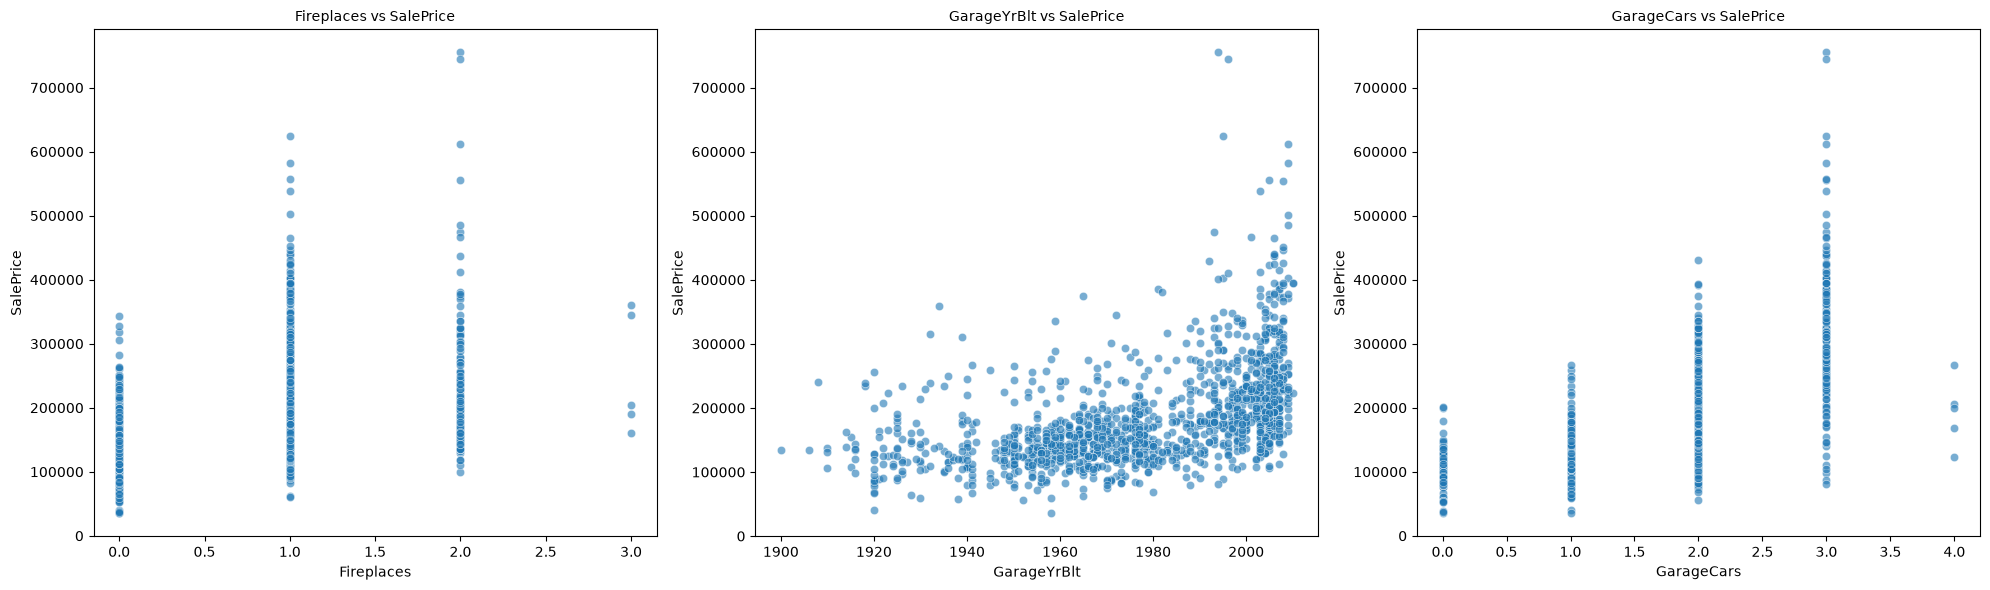

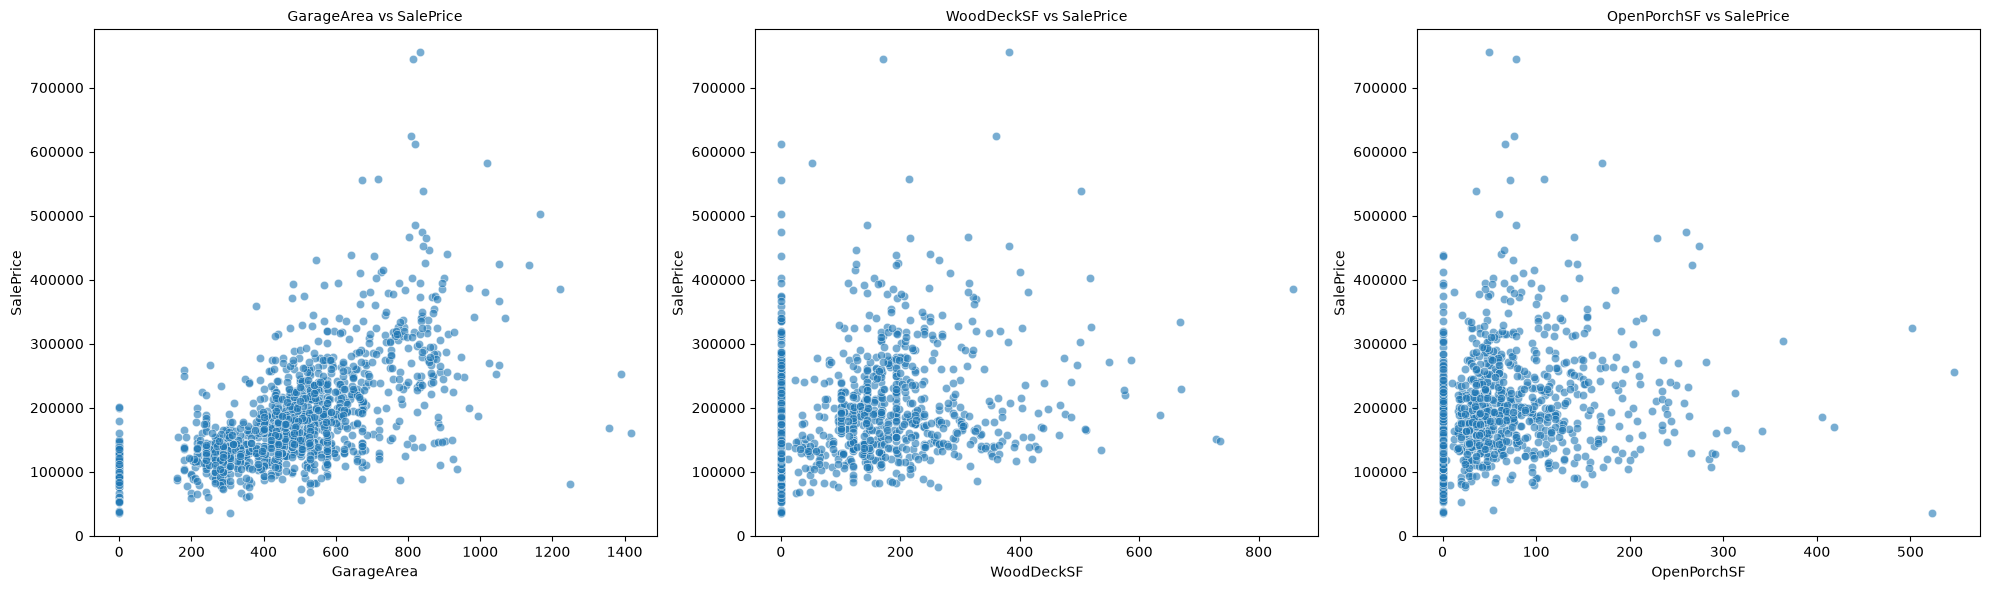

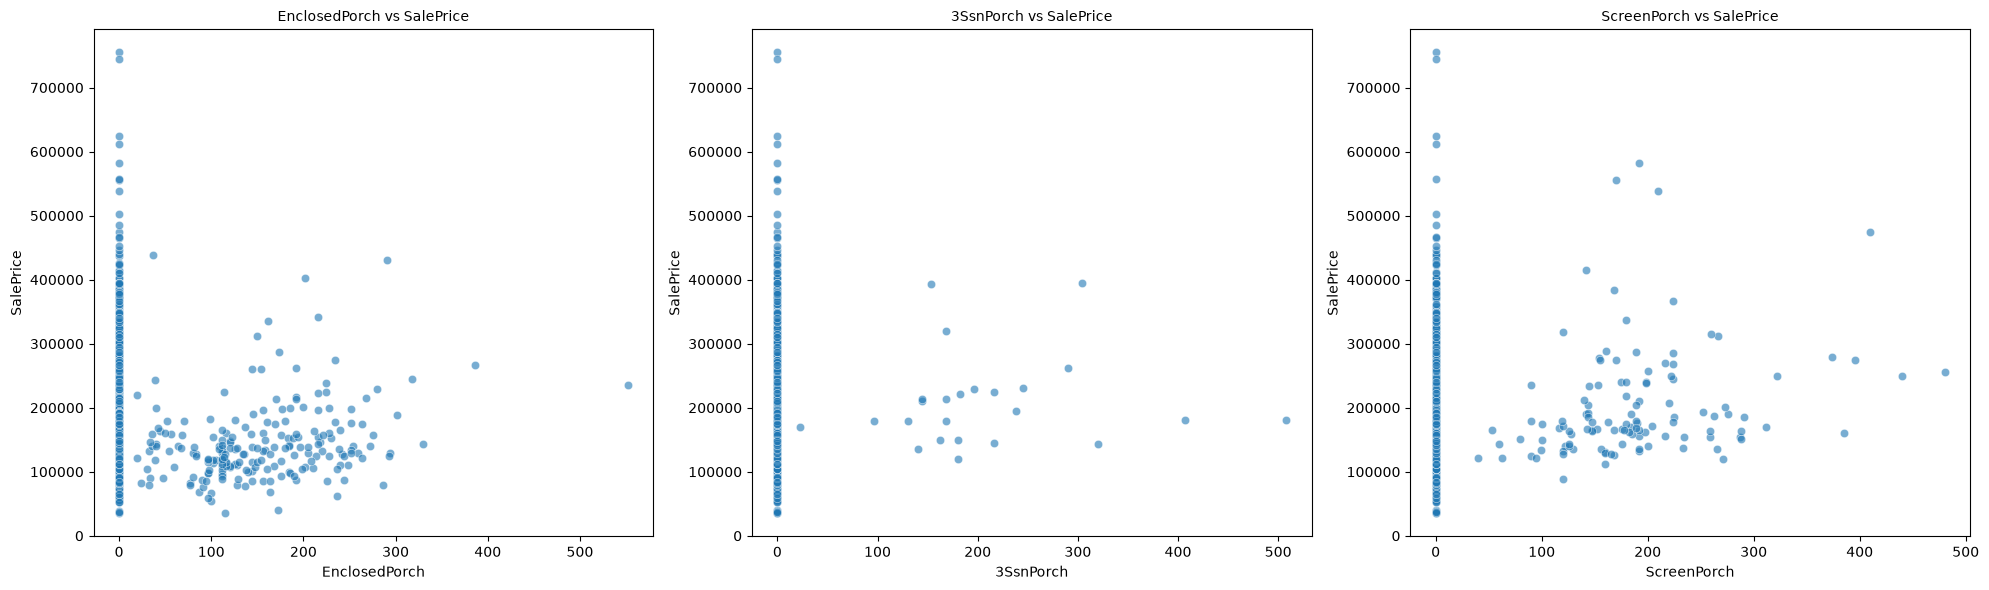

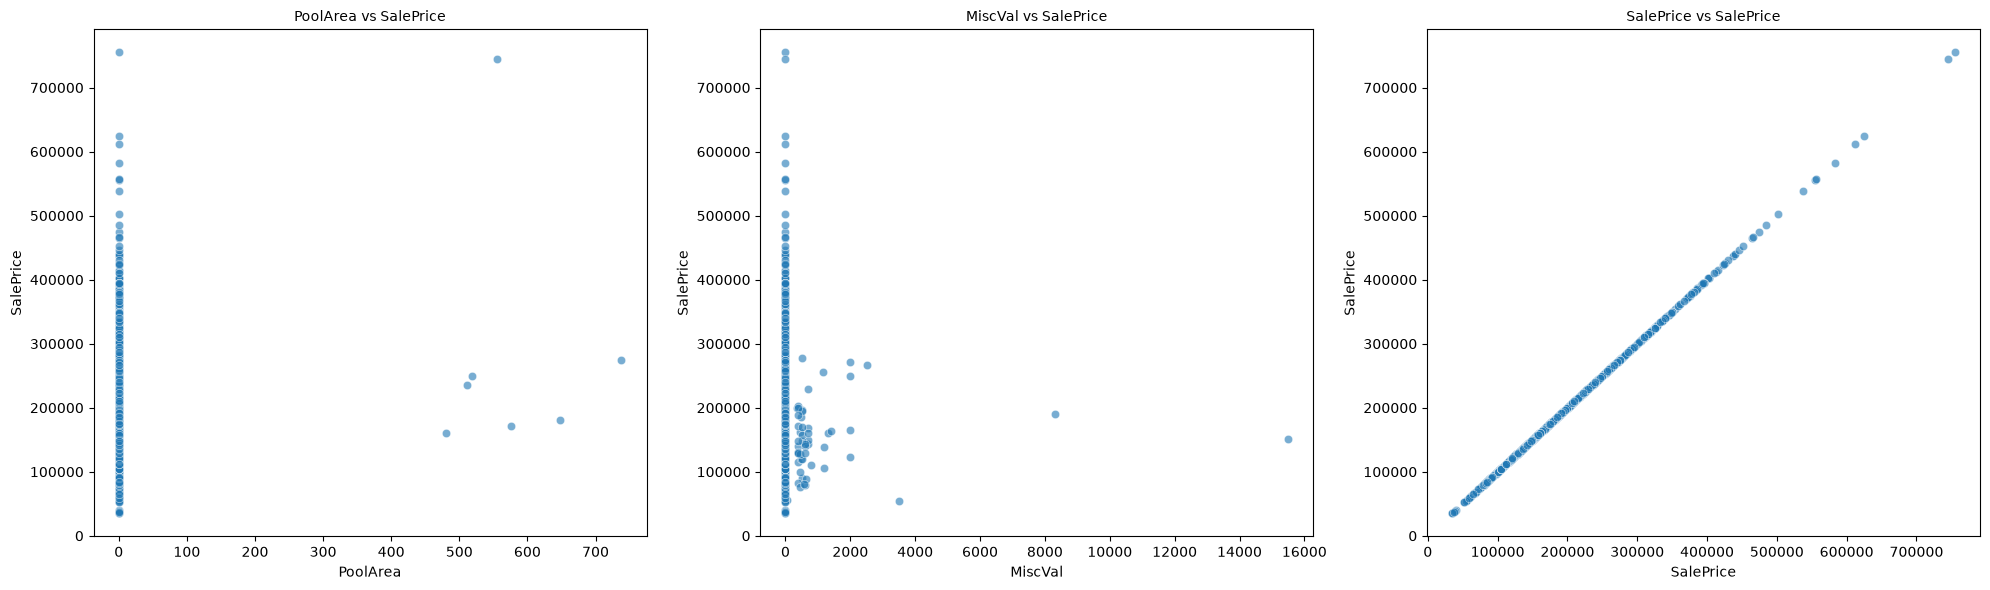

In [115]:
def all_columns_with_price(train_data):  

 # 1. تحديد عدد الميزات في كل صورة
    batch_size = 3
    # 2. تقسيم قائمة الأعمدة إلى مجموعات كل منها 5 ميزات
    cols_list = list(num_con_columns.columns)

    for i in range(0, len(cols_list), batch_size):
        # أخذ 5 أعمدة في كل دورة
        current_batch = cols_list[i : i + batch_size]

        # إنشاء شبكة رسم صف واحد و5 أعمدة
        fig, axes = plt.subplots(1, len(current_batch), figsize=(20, 6))

        # لو الدفعة فيها ميزة واحدة بس، بنخلي axes مصفوفة عشان يشتغل الـ Loop صح
        if len(current_batch) == 1:
            axes = [axes]

        # رسم كل ميزة في مكانها
        for j, col in enumerate(current_batch):
            sns.scatterplot(
                data=train_data, x=col, y="SalePrice", ax=axes[j], alpha=0.6
            )
            axes[j].set_title(f"{col} vs SalePrice", fontsize=10)

        plt.tight_layout()
        plt.show()

all_columns_with_price(train_data)

##### LotFrontage

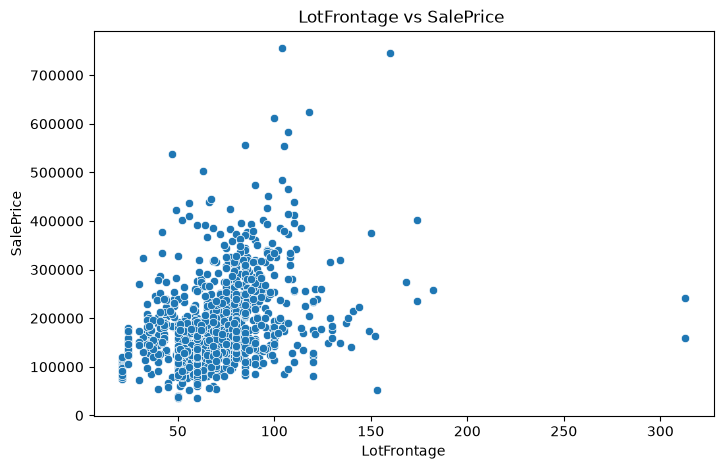

In [116]:
def var_vs_price_fun(var):
    plt.figure(figsize = (8 , 5))
    sns.scatterplot(data = train_data , x = var , y = 'SalePrice')
    plt.title(f'{var} vs SalePrice ')
    plt.show()
var_vs_price_fun('LotFrontage')

In [117]:
# 1. طباعة كل الأعمدة للبيوت الشاّذة عشان نفحصها سوياً
outliers_to_check = train_data.loc[
    train_data['LotFrontage'] > 300, 
    ['LotFrontage', 'LotArea', 'GrLivArea', 'OverallQual', 'YearBuilt', 'SalePrice']
]

# عرض الجدول
outliers_to_check


,LotFrontage,LotArea,GrLivArea,OverallQual,YearBuilt,SalePrice
934,313.0,27650,2069,7,1960,242000
1298,313.0,63887,5642,10,2008,160000


In [118]:
train_data = train_data.drop(1298)
1298 in train_data.index

False

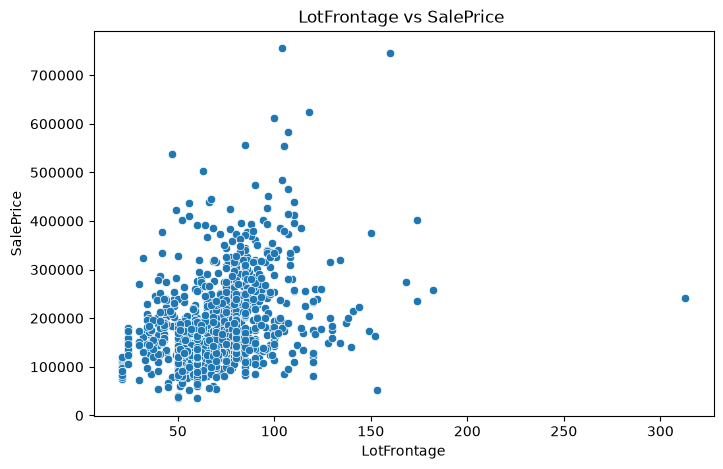

In [119]:
var_vs_price_fun('LotFrontage')

##### LotArea


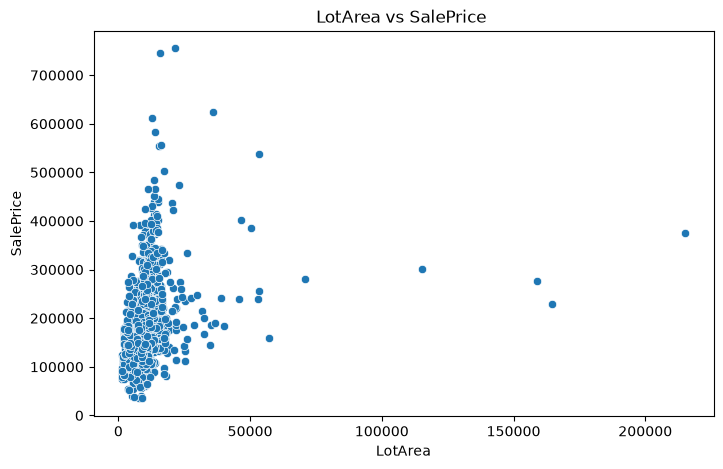

In [120]:
var_vs_price_fun('LotArea')

In [121]:

outliers_to_check = train_data.loc[
    train_data['LotArea'] > 100000 , 
    ['LotFrontage', 'LotArea', 'GrLivArea', 'OverallQual', 'YearBuilt', 'SalePrice']
]
outliers_to_check

,LotFrontage,LotArea,GrLivArea,OverallQual,YearBuilt,SalePrice
249,NaN,159000,2144,6,1958,277000
313,150.0,215245,2036,7,1965,375000
335,NaN,164660,1786,5,1965,228950
706,NaN,115149,1824,7,1971,302000


#### MasVnrArea

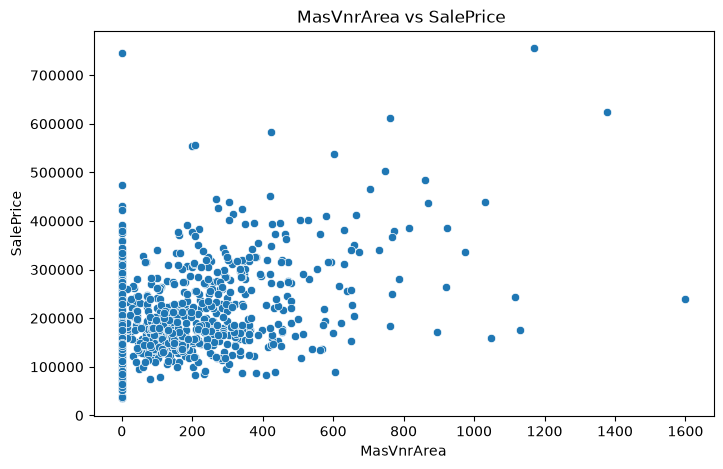

In [122]:
var_vs_price_fun('MasVnrArea')

In [123]:

outliers_to_check = train_data.loc[
    train_data['MasVnrArea'] > 1550 , 
    ['LotFrontage', 'LotArea', 'GrLivArea', 'OverallQual', 'YearBuilt', 'SalePrice']
]
outliers_to_check

,LotFrontage,LotArea,GrLivArea,OverallQual,YearBuilt,SalePrice
297,66.0,7399,1950,7,1997,239000


#### BsmtFinSF1

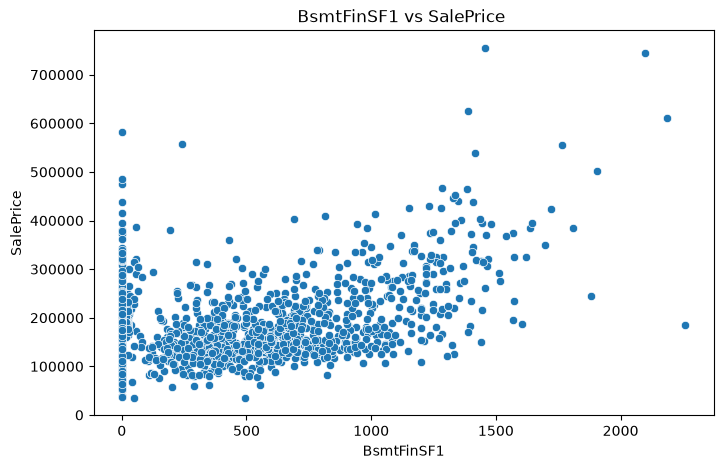

In [124]:
var_vs_price_fun('BsmtFinSF1')

In [125]:
outliers_to_check = train_data.loc[
    (train_data['BsmtFinSF1'] > 2000 ) &  ( train_data['SalePrice'] < 210000 ), 
    ['LotFrontage', 'LotArea', 'GrLivArea', 'OverallQual', 'YearBuilt', 'SalePrice']
]
outliers_to_check

,LotFrontage,LotArea,GrLivArea,OverallQual,YearBuilt,SalePrice
523,130.0,40094,4676,10,2007,184750


In [126]:
train_data = train_data.drop(523 , axis = 0 )
523 in train_data.index

False

#### BsmtFinSF2

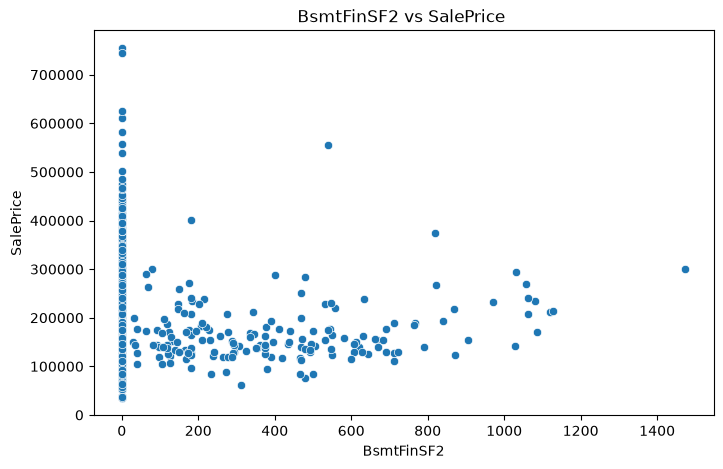

In [127]:
var_vs_price_fun('BsmtFinSF2')

In [128]:
outliers_to_check = train_data.loc[
    train_data['BsmtFinSF2'] > 1400 , 
    ['LotFrontage', 'LotArea', 'GrLivArea', 'OverallQual', 'YearBuilt', 'SalePrice']
]
outliers_to_check

,LotFrontage,LotArea,GrLivArea,OverallQual,YearBuilt,SalePrice
322,86.0,10380,2730,7,1986,301000


#### BsmtUnfSF

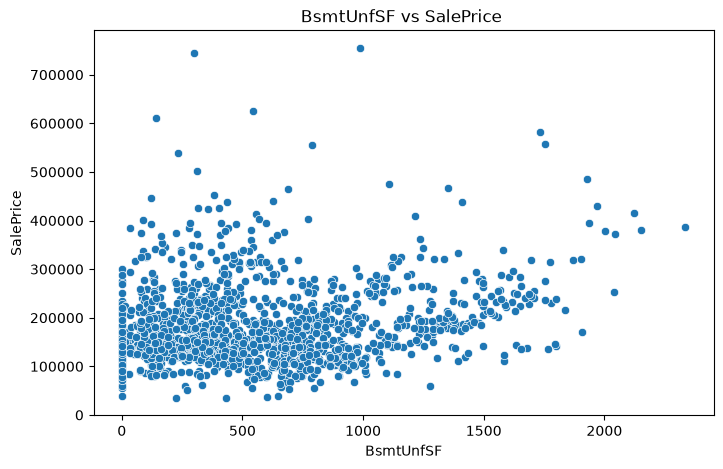

In [129]:
var_vs_price_fun('BsmtUnfSF')

#### TotalBsmtSF

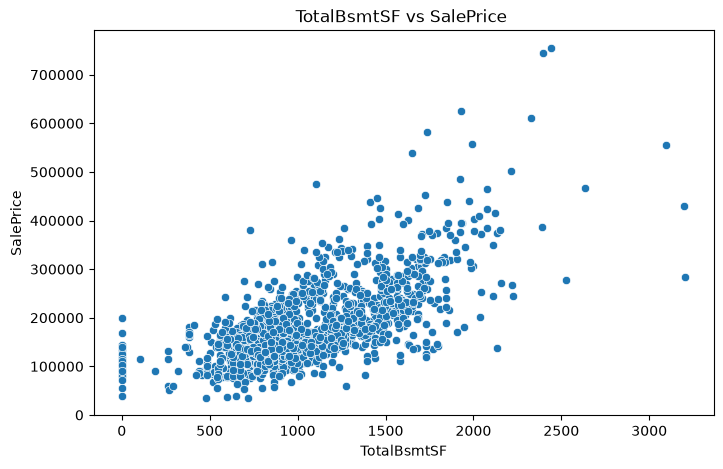

In [130]:
var_vs_price_fun('TotalBsmtSF')

In [131]:
# إعادة ترتيب الـ Index بعد حذف النقط الشاذة
train_data = train_data.reset_index(drop=True)
print("Data shape after removing outliers:", train_data.shape)

Data shape after removing outliers: (1458, 81)


### Nulls

In [132]:
nulls = train_data.isnull().sum()
nulls = nulls[nulls > 0]
nulls

LotFrontage     259
MasVnrArea        8
BsmtQual         37
BsmtCond         37
BsmtExposure     38
BsmtFinType1     37
BsmtFinType2     38
Electrical        1
GarageType       81
GarageYrBlt      81
GarageFinish     81
GarageQual       81
GarageCond       81
dtype: int64

##### Handling with Categorical Columns

In [133]:

cat_cols_nulls = train_data[nulls.index].select_dtypes(
    include=['object', 'string']).isnull().sum()

cat_nulls = cat_cols_nulls[cat_cols_nulls > 0]
cat_nulls

BsmtQual        37
BsmtCond        37
BsmtExposure    38
BsmtFinType1    37
BsmtFinType2    38
Electrical       1
GarageType      81
GarageFinish    81
GarageQual      81
GarageCond      81
dtype: int64

In [134]:
cat_cols_names = train_data[nulls.index].select_dtypes(
    include=['object', 'string']).columns

cat_cols_names

Index(['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Electrical', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond'],
      dtype='str')

In [135]:
train_data[cat_cols_names] = train_data[cat_cols_names].fillna( 'None' )

In [136]:
train_data['Electrical'] = train_data['Electrical'].fillna(
     train_data['Electrical'].mode()[0] )


In [137]:
nulls = train_data.isnull().sum()
nulls = nulls[nulls > 0]
nulls

LotFrontage    259
MasVnrArea       8
GarageYrBlt     81
dtype: int64

##### Handling with Numerical Columns

In [138]:
num_cols_nulls = train_data[nulls.index].select_dtypes(include = np.number).isnull().sum()

num_cols_nulls

LotFrontage    259
MasVnrArea       8
GarageYrBlt     81
dtype: int64

In [139]:
num_cols_names = train_data[nulls.index].select_dtypes(include=np.number).columns
num_cols_names = num_cols_names.drop('GarageYrBlt')
num_cols_names

Index(['LotFrontage', 'MasVnrArea'], dtype='str')

In [140]:
train_data['GarageYrBlt'] = train_data['GarageYrBlt'].fillna(0)

train_data[num_cols_names] = train_data[num_cols_names].fillna(
    train_data[num_cols_names].median() )

train_data.isnull().sum().sum()

np.int64(0)

Text(0.5, 1.0, 'GrLivArea vs SalePrice ')

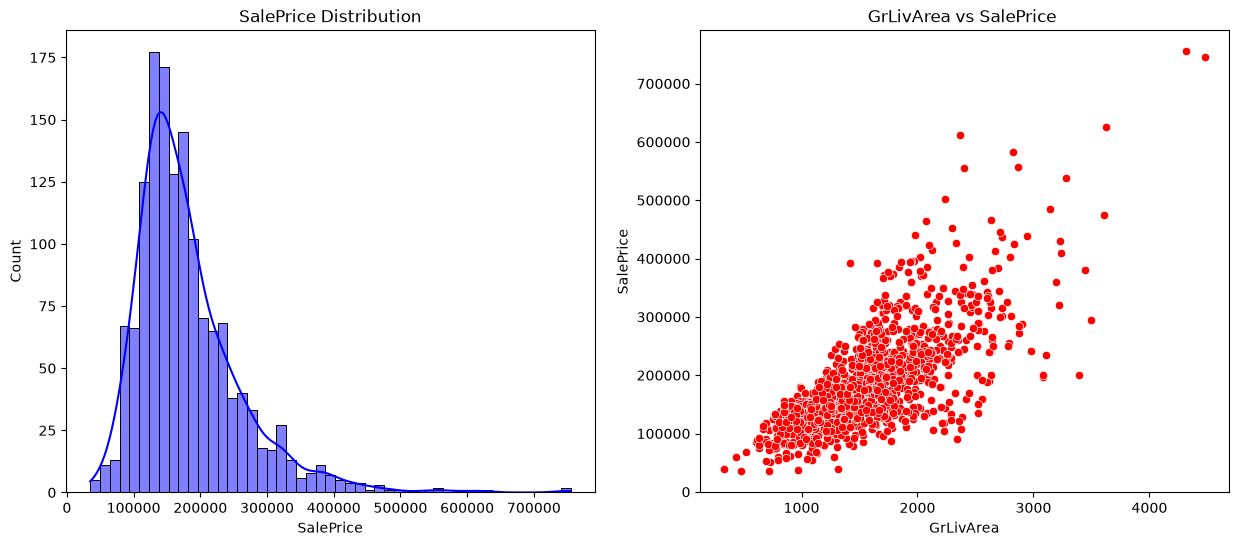

In [141]:
fig , ax = plt.subplots( 1 , 2 , figsize = (15 , 6 ))

sns.histplot(data = train_data , x='SalePrice', kde=True , ax=ax[0], color = 'blue')
ax[0].set_title('SalePrice Distribution')

sns.scatterplot(data=train_data , x='GrLivArea' , y='SalePrice', ax=ax[1],color= 'red')
ax[1].set_title('GrLivArea vs SalePrice ')


Text(0.5, 1.0, 'SalePrice Distribution after(Log1p Trans)')

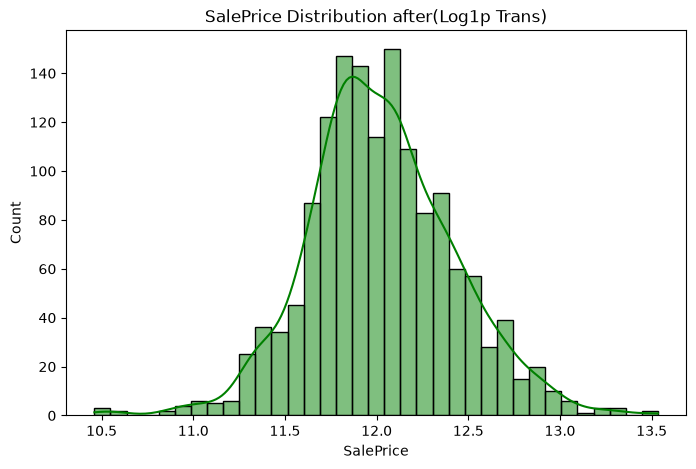

In [142]:
train_data['SalePrice'] = np.log1p(train_data['SalePrice'])

plt.figure(figsize=(8 , 5))
sns.histplot(train_data['SalePrice'], kde=True , color = 'green')
plt.title('SalePrice Distribution after(Log1p Trans)')

#### Features Engineering

In [143]:
# 1. إجمالي مساحة البيت الكلية (إجمالي المساحات فوق وتحت الأرض)
train_data['TotalSF'] = train_data['TotalBsmtSF'] + train_data['1stFlrSF'] + train_data['2ndFlrSF']

# 2. إجمالي عدد الحمامات الكلي في البيت
train_data['TotalBathrooms'] = (train_data['FullBath'] + (0.5 * train_data['HalfBath']) +
                                train_data['BsmtFullBath'] + (0.5 * train_data['BsmtHalfBath']))

# 3. إجمالي مساحة البورندات والحدائق الخارجيات (Porch & Deck)
train_data['TotalPorchSF'] = (train_data['OpenPorchSF'] + train_data['3SsnPorch'] +
                              train_data['EnclosedPorch'] + train_data['ScreenPorch'] +
                              train_data['WoodDeckSF'])

# 4. عمر البيت وقت البيع وعمر التجديد
train_data['HouseAge'] = train_data['YrSold'] - train_data['YearBuilt']
train_data['RemodAge'] = train_data['YrSold'] - train_data['YearRemodAdd']

# 5. ميزات شرطية (هل البيت فيه كراج؟ بدروم؟ دور تاني؟)
train_data['HasGarage'] = ( train_data["GarageArea"] > 0 ).astype(int)
train_data['HasBsmt'] = (train_data['TotalBsmtSF'] > 0).astype(int)
train_data['Has2ndFlr'] = (train_data['2ndFlrSF'] > 0).astype(int)



# هل البيت متجدد؟
train_data['IsRemodeled'] = (
    train_data['YearBuilt'] != train_data['YearRemodAdd']
).astype(int)



In [144]:
train_data.shape

(1458, 90)

#### Categorical Encoding

In [145]:

train_data = pd.get_dummies(train_data , drop_first=True)
train_data.head(5)
train_data.shape

(1458, 270)